In [ ]:
import yfinance as yf

msft = yf.Ticker("MSFT")
data = msft.history(period="15y")
data.to_csv("microsoft_stock_data.csv")

print("Download complete! First 5 rows:")
print(data.head())

Download complete! First 5 rows:
                                Open       High        Low      Close  \
Date                                                                    
2011-04-11 00:00:00-04:00  20.052708  20.098647  19.754099  19.891918   
2011-04-12 00:00:00-04:00  19.777076  19.792389  19.562690  19.631599   
2011-04-13 00:00:00-04:00  19.639251  19.807698  19.570341  19.623938   
2011-04-14 00:00:00-04:00  19.463148  19.478462  19.210479  19.463148   
2011-04-15 00:00:00-04:00  19.493782  19.570348  19.279397  19.424873   

                             Volume  Dividends  Stock Splits  
Date                                                          
2011-04-11 00:00:00-04:00  34286300        0.0           0.0  
2011-04-12 00:00:00-04:00  36920400        0.0           0.0  
2011-04-13 00:00:00-04:00  38144700        0.0           0.0  
2011-04-14 00:00:00-04:00  55239900        0.0           0.0  
2011-04-15 00:00:00-04:00  65080400        0.0           0.0  


In [ ]:
data.describe()
data = data.reset_index()

In [ ]:
# SMA 20day
data['SMA_20'] = data['Close'].rolling(window=20).mean()

# RSI 14day reff
delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

# MACD
exp1 = data['Close'].ewm(span=12, adjust=False).mean()
exp2 = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD'] = exp1 - exp2

data.dropna(inplace=True)
df= data[['Close', 'High', 'Low', 'Volume', 'SMA_20', 'RSI', 'MACD']]
df

,Close,High,Low,Volume,SMA_20,RSI,MACD
19,19.777065,19.876601,19.654559,38696400,19.730363,59.493544,0.009984
20,19.654558,19.792378,19.332980,120798700,19.718495,56.435591,-0.003303
21,19.417202,19.646900,19.302351,78600000,19.707775,44.652339,-0.032610
22,19.386576,19.440172,19.218130,77400000,19.695907,47.175070,-0.057642
23,19.164541,19.386583,19.103288,66812300,19.680976,42.246042,-0.094310
...,...,...,...,...,...,...,...
3765,369.369995,373.989990,368.200012,29417200,387.357999,26.908355,-12.225462
3766,373.459991,373.640015,364.149994,24099100,385.496999,33.788371,-11.431076
3767,372.880005,373.730011,369.500000,16146600,383.692999,28.953520,-10.724691
3768,372.290009,372.450012,366.559998,21443300,381.837000,28.931032,-10.096103


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3751 entries, 19 to 3769
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3751 non-null   float64
 1   High    3751 non-null   float64
 2   Low     3751 non-null   float64
 3   Volume  3751 non-null   int64  
 4   SMA_20  3751 non-null   float64
 5   RSI     3751 non-null   float64
 6   MACD    3751 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 234.4 KB


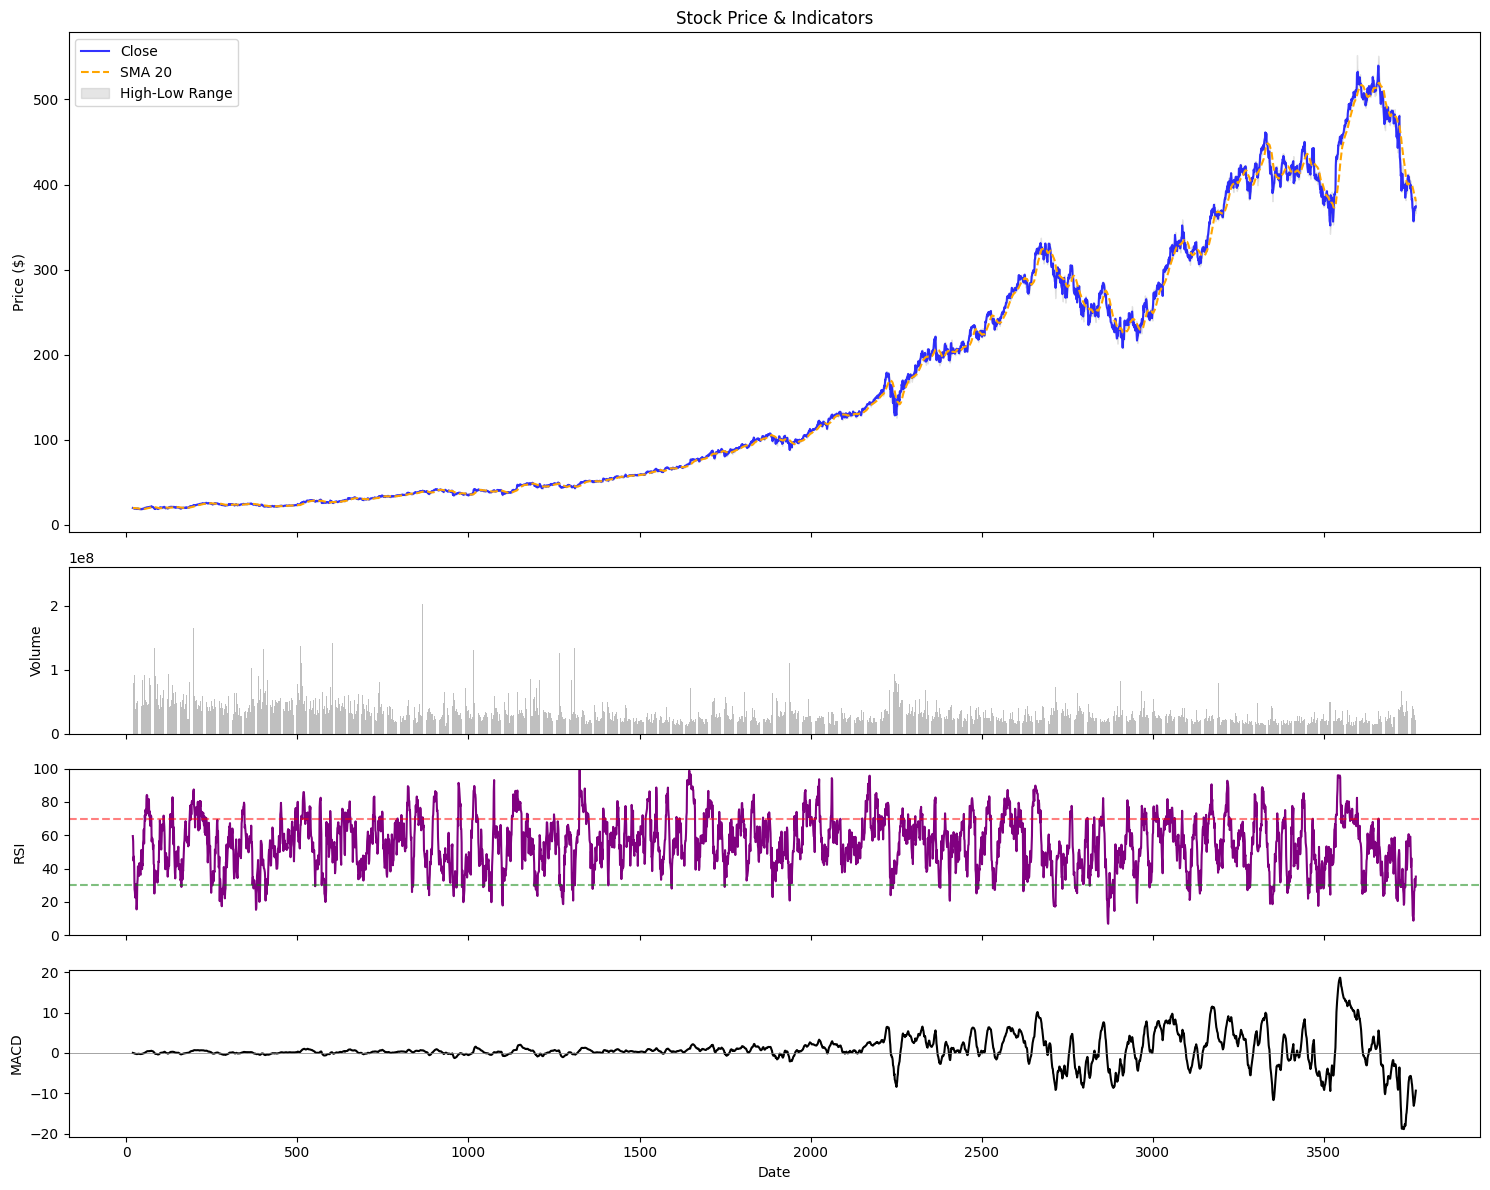

In [ ]:
import matplotlib.pyplot as plt


fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True,
                                         gridspec_kw={'height_ratios': [3, 1, 1, 1]})

# 1. Main Price Plot (Close, High, Low, SMA)
ax1.plot(df.index, df['Close'], label='Close', color='blue', alpha=0.8)
ax1.plot(df.index, df['SMA_20'], label='SMA 20', color='orange', linestyle='--')
ax1.fill_between(df.index, df['Low'], df['High'], color='gray', alpha=0.2, label='High-Low Range')
ax1.set_title('Stock Price & Indicators')
ax1.legend(loc='upper left')
ax1.set_ylabel('Price ($)')

# Volume Plot
ax2.bar(df.index, df['Volume'], color='gray', alpha=0.5)
ax2.set_ylabel('Volume')

# RSI Plot
ax3.plot(df.index, df['RSI'], color='purple')
ax3.axhline(70, color='red', linestyle='--', alpha=0.5) # overbought line
ax3.axhline(30, color='green', linestyle='--', alpha=0.5) # oversold line
ax3.set_ylabel('RSI')
ax3.set_ylim(0, 100)

# MACD Plot
ax4.plot(df.index, df['MACD'], color='black', label='MACD')
ax4.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax4.set_ylabel('MACD')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)
training_size = int(len(scaled_data) * 0.65)
train_data = scaled_data[0:training_size, :]
test_data = scaled_data[training_size:len(scaled_data), :]

In [ ]:
import numpy as np

def create_multivariate_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        dataX.append(dataset[i:(i + time_step), :])
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

X_train, y_train = create_multivariate_dataset(train_data, 100)
X_test, y_test = create_multivariate_dataset(test_data, 100)

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),

    LSTM(100, return_sequences=False),
    Dropout(0.2),

    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0017 - val_loss: 0.0061
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.3394e-04 - val_loss: 7.6343e-04
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8965e-04 - val_loss: 0.0017
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5743e-04 - val_loss: 0.0023
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5398e-04 - val_loss: 0.0017
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.4040e-04 - val_loss: 8.6415e-04
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.6322e-04 - val_loss: 0.0214
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.3751e-04 - val_loss: 8.6830e-04
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.3416e-04 - val_loss: 0.0029
Epoch 10/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.1204e-04 - val_loss: 9.4630e-04
Epoch 11/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.0627e-04 - val_loss: 7.0

In [ ]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

def inverse_transform_only_close(scaler, predictions, n_features):
    dummy = np.zeros((len(predictions), n_features))
    dummy[:, 0] = predictions.flatten()
    return scaler.inverse_transform(dummy)[:, 0]


n_feats = 7
train_predict_real = inverse_transform_only_close(scaler, train_predict, n_feats)
test_predict_real = inverse_transform_only_close(scaler, test_predict, n_feats)

y_train_real = inverse_transform_only_close(scaler, y_train, n_feats)
y_test_real = inverse_transform_only_close(scaler, y_test, n_feats)

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
import math
from sklearn.metrics import mean_squared_error, r2_score


train_rmse = math.sqrt(mean_squared_error(y_train_real, train_predict_real))
test_rmse = math.sqrt(mean_squared_error(y_test_real, test_predict_real))


r2 = r2_score(y_test_real, test_predict_real)

print(f"Train RMSE: ${train_rmse:.2f}")
print(f"Test RMSE: ${test_rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

Train RMSE: $2.55
Test RMSE: $11.17
R2 Score: 0.9829


In [ ]:
import numpy as np
import pandas as pd

last_100_days = test_data[-100:].reshape(1, 100, 7)
temp_input = list(last_100_days[0])
lst_output = []

for i in range(30):
    current_input = np.array(temp_input[-100:]).reshape(1, 100, 7)


    yhat = model.predict(current_input, verbose=0)


    last_row = temp_input[-1].copy()
    last_row[0] = yhat[0][0]

    lst_output.append(yhat[0][0])
    temp_input.append(last_row)


dummy_april = np.zeros((30, 7))
dummy_april[:, 0] = np.array(lst_output)
april_forecast_prices = scaler.inverse_transform(dummy_april)[:, 0]

In [ ]:
monthly_average = np.mean(april_forecast_prices)
monthly_max = np.max(april_forecast_prices)
monthly_min = np.min(april_forecast_prices)

print(f"--- April 2026 Forecast Summary ---")
print(f"Average Predicted Price: ${monthly_average:.2f}")
print(f"Predicted Monthly High:  ${monthly_max:.2f}")
print(f"Predicted Monthly Low:   ${monthly_min:.2f}")

--- April 2026 Forecast Summary ---
Average Predicted Price: $383.57
Predicted Monthly High:  $385.07
Predicted Monthly Low:   $378.45


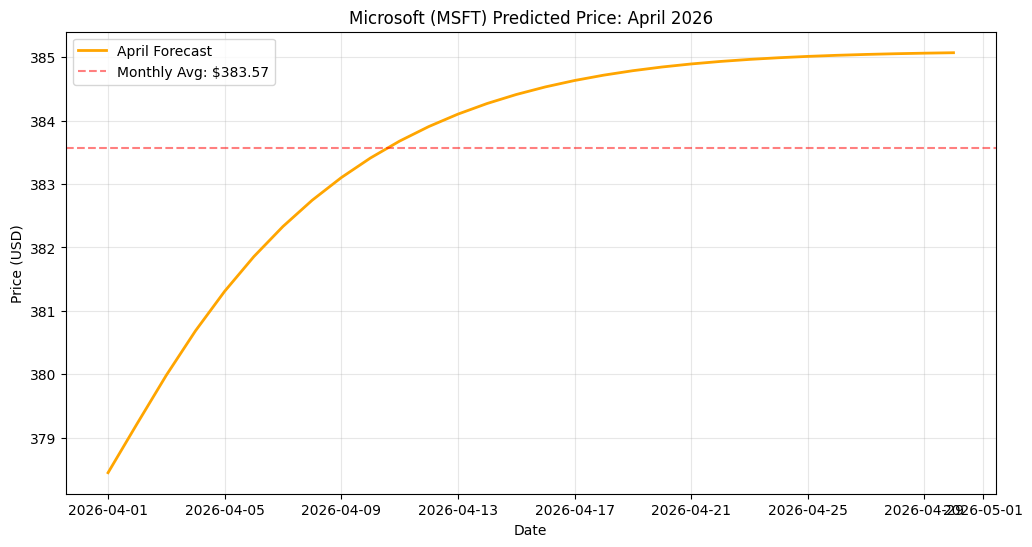

In [ ]:
import matplotlib.pyplot as plt

last_date = pd.to_datetime("2026-03-31")
april_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)
plt.figure(figsize=(12, 6))


plt.plot(april_dates, april_forecast_prices, label='April Forecast', color='orange', linewidth=2)

plt.axhline(y=monthly_average, color='red', linestyle='--', alpha=0.5,
            label=f'Monthly Avg: ${monthly_average:.2f}')

plt.title("Microsoft (MSFT) Predicted Price: April 2026")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np


prediction_dates = pd.date_range(start="2026-04-01", periods=30)

n_features = 7
dummy = np.zeros((len(lst_output), n_features))
dummy[:, 0] = np.array(lst_output).flatten()
month_prices = scaler.inverse_transform(dummy)[:, 0]


april_forecast = pd.DataFrame({
    'Date': prediction_dates,
    'Predicted_Price': month_prices
})

april_forecast['Predicted_Price'] = april_forecast['Predicted_Price'].round(2)
april_forecast.columns = ['Date', 'Predicted Close Price (USD)']
print(april_forecast.to_string(index=False))

      Date  Predicted Close Price (USD)
2026-04-01                       378.45
2026-04-02                       379.23
2026-04-03                       379.99
2026-04-04                       380.69
2026-04-05                       381.31
2026-04-06                       381.86
2026-04-07                       382.33
2026-04-08                       382.74
2026-04-09                       383.10
2026-04-10                       383.41
2026-04-11                       383.68
2026-04-12                       383.90
2026-04-13                       384.10
2026-04-14                       384.27
2026-04-15                       384.41
2026-04-16                       384.53
2026-04-17                       384.63
2026-04-18                       384.71
2026-04-19                       384.78
2026-04-20                       384.84
2026-04-21                       384.89
2026-04-22                       384.93
2026-04-23                       384.96
2026-04-24                       384.99
